In [ ]:
# ============================================================
# FAKE NEWS DETECTION - CA Submission
# Dataset: LIAR Dataset (via HuggingFace datasets)
# Model: TF-IDF + Logistic Regression
# ============================================================

In [3]:
# ── 1. Install & Imports ──────────────────────────────────
import pandas as pd
import numpy as np
import re, string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
#Load dataset
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

fake_df["binary_label"] = 1   # FAKE
true_df["binary_label"] = 0   # REAL

df = pd.concat([fake_df, true_df], ignore_index=True)
df = df.dropna(subset=["text"])

print("Dataset shape:", df.shape)
print(df["binary_label"].value_counts().rename({0:"Real", 1:"Fake"}))

Dataset shape: (44898, 5)
binary_label
Fake    23481
Real    21417
Name: count, dtype: int64


In [7]:
# from google.colab import drive
# drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [8]:
# ── 3. Preprocessing ──────────────────────────────────────
# Raw text has noise — punctuation, URLs, mixed case
# Cleaning ensures "Fake!" and "fake" are treated as the same word

def clean(text):
    text = text.lower()                                                    # "Fake" → "fake"
    text = re.sub(r"http\S+", "", text)                                    # remove URLs
    text = text.translate(str.maketrans("", "", string.punctuation))       # remove .,!? etc
    text = re.sub(r"\s+", " ", text).strip()                               # collapse extra spaces
    return text

df["clean_text"] = (df["title"].fillna("") + " " + df["text"].fillna("")).apply(clean)

X = df["clean_text"]
y = df["binary_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    # stratify=y → keeps same Fake/Real ratio in both splits
)

In [9]:
# ── 4. TF-IDF Vectorization ───────────────────────────────
# Machines can't read words — they need numbers
# TF  (Term Frequency)   = how often a word appears in THIS document
# IDF (Inverse Doc Freq) = how rare the word is across ALL documents
# TF-IDF score = TF × IDF
# Common words like "the", "is" get penalized. Rare meaningful words get higher scores.
# ngram_range=(1,2) → captures single words AND two-word phrases like "not true"
# max_features=10000 → top 10,000 most useful words/phrases

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words="english")
X_train_vec = tfidf.fit_transform(X_train)   # learn vocab from train, then convert
X_test_vec  = tfidf.transform(X_test)        # only convert — avoids data leakage

In [10]:
# ── 5. Train Model ────────────────────────────────────────
# Logistic Regression finds best weighted combination of
# TF-IDF features to separate FAKE from REAL
# C=1.0 is regularization strength — prevents overfitting

model = LogisticRegression(max_iter=1000, C=1.0)
model.fit(X_train_vec, y_train)
print("Model trained!")

Model trained!


In [11]:
# ── 6. Evaluate ───────────────────────────────────────────
y_pred = model.predict(X_test_vec)

print("\n── Accuracy ──")
print(f"{accuracy_score(y_test, y_pred)*100:.2f}%")

print("\n── Classification Report ──")
# Precision = of all predicted FAKE, how many were actually fake?
# Recall    = of all actual FAKE, how many did we catch?
# F1-Score  = harmonic mean of precision and recall
print(classification_report(y_test, y_pred, target_names=["Real", "Fake"]))


── Accuracy ──
98.95%

── Classification Report ──
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      4284
        Fake       0.99      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



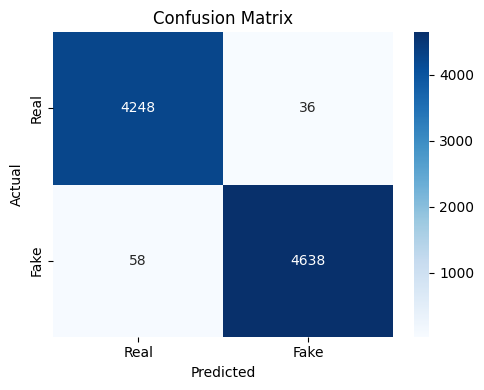

In [12]:
# ── 7. Confusion Matrix ───────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real","Fake"], yticklabels=["Real","Fake"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


In [13]:
# ── 8. Top words → FAKE / REAL ───────────────────────────
feature_names = tfidf.get_feature_names_out()
coefficients  = model.coef_[0]

top_fake_idx = np.argsort(coefficients)[-15:][::-1]
top_real_idx = np.argsort(coefficients)[:15]

print("\nTop words → FAKE:", [feature_names[i] for i in top_fake_idx])
print("Top words → REAL:", [feature_names[i] for i in top_real_idx])



Top words → FAKE: ['video', 'just', 'image', 'hillary', 'gop', 'president trump', 'mr', 'obama', 'america', 'like', 'breaking', 'images', 'watch', 'american', 'president obama']
Top words → REAL: ['reuters', 'said', 'washington reuters', 'president donald', 'wednesday', 'washington', 'tuesday', 'republican', 'reuters president', 'thursday', 'friday', 'monday', 'nov', 'said statement', 'edt']


In [14]:
# ── 9. Predict Custom Input ───────────────────────────────
def predict(text):
    vec   = tfidf.transform([clean(text)])
    pred  = model.predict(vec)[0]
    prob  = model.predict_proba(vec)[0]
    label = "FAKE" if pred == 1 else "REAL"
    print(f"\nStatement : {text}")
    print(f"Prediction: {label}  ({max(prob)*100:.1f}% confidence)")

predict("The Federal Reserve raised interest rates by 0.25 percent on Wednesday.")
predict("The unemployment rate dropped to 3.5% last quarter.")
predict("Scientists confirm vaccines cause autism in children.")


Statement : The Federal Reserve raised interest rates by 0.25 percent on Wednesday.
Prediction: REAL  (81.7% confidence)

Statement : The unemployment rate dropped to 3.5% last quarter.
Prediction: FAKE  (68.9% confidence)

Statement : Scientists confirm vaccines cause autism in children.
Prediction: FAKE  (82.9% confidence)


In [15]:
import random

# ── Sample 10 random statements from dataset ─────────────
samples = df.sample(10, random_state=random.randint(0, 9999))[["clean_text", "binary_label"]]

print("=" * 60)
print("   TEST THESE STATEMENTS — Copy & paste into the box below")
print("=" * 60)

for i, (_, row) in enumerate(samples.iterrows(), 1):
    actual = "FAKE" if row["binary_label"] == 1 else "REAL"
    # Show first 120 chars only to keep it readable
    preview = row["clean_text"][:120].strip()
    print(f"\n{i:2}. [{actual}] {preview}...")

print("\n" + "=" * 60)
print("Now type any of the above into the Check News box!")
print("=" * 60)

   TEST THESE STATEMENTS — Copy & paste into the box below

 1. [FAKE] how one teacher responded after nearly losing a student to suicide video brittni darras teaches english at rampart high...

 2. [FAKE] racist gop rep steve king goes ballistic over trump’s daca deal this is what happens when racists don t get their waywit...

 3. [FAKE] hillary blasts antiwoman antiimmigrant republicans in glorious gopdebate live tweets thursday night marked the seventh g...

 4. [FAKE] hillary’s ‘russian hack’ hoax the biggest lie of this election season patrick henningsen 21st century wirethe longer thi...

 5. [REAL] may says will honor commitments to eu brussels reuters prime minister theresa may said on friday she had told fellow eu...

 6. [REAL] trump to meet with petraeus corker romney this week transition team washington reuters presidentelect donald trump this...

 7. [FAKE] wow ratings are in for antitrumper megyn kelly’s debut show on nbc…and they’re pretty bad here is the interview that

In [16]:
import ipywidgets as widgets
from IPython.display import display

text_input = widgets.Textarea(
    placeholder="Type a news statement here...",
    layout=widgets.Layout(width="600px", height="80px")
)

button = widgets.Button(
    description="Check News",
    button_style="primary"
)

output = widgets.Output()

def on_click(b):
    output.clear_output()
    with output:
        user_text = text_input.value.strip()
        if user_text == "":
            print("Please enter a statement.")
            return
        vec   = tfidf.transform([clean(user_text)])
        pred  = model.predict(vec)[0]
        prob  = model.predict_proba(vec)[0]
        label = "🔴 FAKE NEWS" if pred == 1 else "🟢 REAL NEWS"
        conf  = max(prob) * 100
        print(f"Result     : {label}")
        print(f"Confidence : {conf:.1f}%")

button.on_click(on_click)

display(text_input, button, output)

Textarea(value='', layout=Layout(height='80px', width='600px'), placeholder='Type a news statement here...')

Button(button_style='primary', description='Check News', style=ButtonStyle())

Output()

"The model detects fake news based on linguistic patterns learned from news articles, not factual verification.
Short factual statements may be misclassified because they don't match the writing style of the training data."

